# # PaCMAP visualization of candidate questions and parliamentary cases

This notebook visualizes the high-dimensional semantic embedding space created with multilingual E5 using **PaCMAP (Pairwise Controlled Manifold Approximation Projection)**. PaCMAP reduces the E5 embeddings to two dimensions while attempting to preserve both local neighbourhood relationships and broader global structure.

The aim is to examine how candidate-test questions and parliamentary cases are positioned relative to one another in the semantic space. In particular, we want to see whether candidate questions are located near parliamentary cases that address similar political issues, and whether broader thematic structures emerge across the full collection of texts.

The PaCMAP projection is used here as an exploratory visualization. Distances in the two-dimensional plot should not be interpreted as direct cosine-similarity scores; the original E5 embeddings remain the basis for semantic retrieval and similarity calculations.


In [3]:
# %pip install pacmap

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 32.7 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ----------- ---------------------------- 11.8/41.9 MB 67.1 MB/s eta 0:00:01
   ---------------------- ----------------- 23.9/41.9 MB 55.9 MB/s eta 0:00:01
   ---------------------------------- ----- 35.9/41.9 MB 55.6 MB/s eta 0:00:01
   ---------------------------------------- 41.9/41.9 MB 53.2 MB/s  0:00:00
   ---------------------------------------- 0.0/16.2 MB ? eta -:--:--
   ----------------------------- ---------- 11.8/16.2 MB 61.4 MB/s eta 0:00:01
   ---------------------------------------  16.0/16.2 MB 41.9 MB/s eta 0:00:01
   ---------------------------------------- 16.2/16.2 MB 36.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [llvmlite]
   ---------------------------------------- 0/4 [llvmlite]
   ---------------------------------------- 0/4 [ll

In [53]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

import pacmap

In [54]:
DATA_DIR = Path("../data/temp_data")

candidate_test_file = (
    DATA_DIR / "candidate_test" / "Kandidattestdata.xlsx"
)

roll_calls_file = (
    DATA_DIR / "parliament" / "roll_calls_resume.csv"
)

## Load Parliamentary Data

In [55]:
df_roll_calls = pd.read_csv(
    roll_calls_file
)

df_roll_calls.head()

,afstemningid,sagstrinid,kommentar,afstemningstypeid,dato,sagstrintypeid,sagid,sagstypeid,sag_nummer,sag_titel,sag_titelkort,sag_resume
0,2,4849,NaN,1,2014-09-09 09:15:00,17,1449,3,L 200,Forslag til lov om ændring af virksomhedsskatteloven og kildeskatteloven. (Indgreb mod utilsigtet udnyttelse af virksomhedsordningen ved indskud af privat gæld m.v.).,Om indgreb mod utilsigtet udnyttelse af virksomhedsordningen ved indskud af privat gæld m.v.,"Loven ændrer virksomhedsskatteordningens regler, så det sikres, at selvstændigt erhvervsdrivende ikke kan udnytte virksomhedsskatteordningen utilsigtet. Med loven sikres det, at selvstændige ikke kan anvende lavt beskattede midler til at finansiere privatforbrug og afdrage på privat gæld, uden at midlerne beskattes som personlig indkomst. Der ændres ikke på virksomhedsskatteordningens grundlæggende struktur og indhold.\n\nLoven indeholder følgende elementer:\n- Selvstændige kan fremover kun spare op i virksomhedsordningen, hvis indskudskontoen er nul eller positiv. \n- Hvis aktiver, der indgår i virksomhedsordningen, fremover stilles til sikkerhed for gæld, der ikke indgår i virksomhedsordningen, anses et tilsvarende beløb for hævet af den selvstændige.\n- Rentekorrektionen forhøjes effektivt med 3 procentpoint med henblik på at eliminere den skattemæssige besparelse, som selvstændige kan opnå ved at placere private renteudgifter i virksomhedsordningen.\n- For selvstændige, der ved lovforslagets fremsættelse anvender virksomhedsordningen, og som allerede har stillet virksomhedens aktiver til sikkerhed for gæld, der ikke indgår i ordningen, eller har en negativ indskudskonto, suspenderes muligheden for at spare op i ordningen. Det gælder dog kun, hvis summen af den nominelle værdi af den negative indskudskonto og en evt. sikkerhedsstillelse overstiger 100.000 kr.\n\nBegrænsningerne i forhold til opsparingsmuligheden og forhøjelsen af rentekorrektionssatsen skønnes at indebære et umiddelbart merprovenu på ca. 0,8 mia. kr. i 2014, ca. 0,9 mia.kr. i 2015 og ca. 0,8 mia. kr. fra og med 2016. Den varige umiddelbare provenuvirkning skønnes at udgøre ca. 0,65 mia. kr. og ca. 0,5 mia. kr. efter tilbageløb.\n\nFor hurtigst muligt at give selvstændige klarhed om de nye regler, og da dele af loven skulle have virkning allerede fra og med fremsættelsen af lovforslaget af hensyn til indgrebets effektivitet og hindring af hamstring, er loven blevet vedtaget i indeværende folketingsår."
1,1783,37246,NaN,1,2014-10-31 10:00:00,17,12715,3,L 4,"Forslag til lov om ændring af lov om afgift af elektricitet, lov om afgift af stenkul, brunkul og koks m.v., personskatteloven og forskellige andre love. (Tilbagerulning af forsyningssikkerhedsafgiften, nedsættelse af elvarmeafgiften, forhøjelse af elafgiften, tilpasning af afgiftsregler for VE-brændsler, forhøjelse af bundskatten og det skrå skatteloft, nedsættelse af den grønne check og afgiftsforhøjelse på cigarillos m.v.).",Om tilbagerulning af forsyningssikkerhedsafgiften m.v.,"Lovforslaget betyder, at afgiftsforhøjelserne på fossile brændsler og den nye afgift på VE-brændsler, der følger af forsyningssikkerhedsafgiften, afskaffes fra den 1. januar 2015. Derudover nedsættes energiafgifterne på fossile brændsler (olie, kul og gas) med 7,9 kr./GJ, og elvarmeafgiften nedsættes parallelt. Desuden justeres afgifterne vedrørende bioolier m.v. Samlet skønnes tilbagerulningen af forsyningssikkerhedsafgiften m.v. at indebære et mindreprovenu efter indregning af tilbageløb og adfærdsændringer på ca. 3,0 mia. kr. (2014-niveau) i 2020. Tilbagerulningen finansieres ved en forhøjelse af bundskattesatsen og det skrå skatteloft med 0,28 procentpoint og en reduktion af den grønne check med 425 kr. i 2020 (fra 1.300 kr. til 875 kr.), når tilbagerulningen er fuldt indfaset. \n\nDer gennemføres derudover en erhvervsrettet lempelse af PSO for el på knap 1 mia. kr. årligt i 2015 og 2016 stigende til ca. 1,6 mia. kr. årligt fra 2017 og frem. Efter indregning af tilbageløb og adfærdsæn

In [56]:
df_cases = (
    df_roll_calls[
        [
            "sagid",
            "sag_nummer",
            "sag_titel",
            "sag_titelkort",
            "sag_resume",
            "dato",
        ]
    ]
    .drop_duplicates(subset="sagid")
    .reset_index(drop=True)
)

In [57]:
df_cases["text"] = (
    df_cases["sag_titel"].fillna("")
    + " "
    + df_cases["sag_resume"].fillna("")
)

In [58]:
print("Number of parliamentary cases:", len(df_cases))

df_cases[
    [
        "sagid",
        "sag_nummer",
        "sag_titel",
        "sag_resume",
    ]
].head()

Number of parliamentary cases: 2128


,sagid,sag_nummer,sag_titel,sag_resume
0,1449,L 200,Forslag til lov om ændring af virksomhedsskatteloven og kildeskatteloven. (Indgreb mod utilsigtet udnyttelse af virksomhedsordningen ved indskud af privat gæld m.v.).,"Loven ændrer virksomhedsskatteordningens regler, så det sikres, at selvstændigt erhvervsdrivende ikke kan udnytte virksomhedsskatteordningen utilsigtet. Med loven sikres det, at selvstændige ikke kan anvende lavt beskattede midler til at finansiere privatforbrug og afdrage på privat gæld, uden at midlerne beskattes som personlig indkomst. Der ændres ikke på virksomhedsskatteordningens grundlæggende struktur og indhold.\n\nLoven indeholder følgende elementer:\n- Selvstændige kan fremover kun spare op i virksomhedsordningen, hvis indskudskontoen er nul eller positiv. \n- Hvis aktiver, der indgår i virksomhedsordningen, fremover stilles til sikkerhed for gæld, der ikke indgår i virksomhedsordningen, anses et tilsvarende beløb for hævet af den selvstændige.\n- Rentekorrektionen forhøjes effektivt med 3 procentpoint med henblik på at eliminere den skattemæssige besparelse, som selvstændige kan opnå ved at placere private renteudgifter i virksomhedsordningen.\n- For selvstændige, der ved lovforslagets fremsættelse anvender virksomhedsordningen, og som allerede har stillet virksomhedens aktiver til sikkerhed for gæld, der ikke indgår i ordningen, eller har en negativ indskudskonto, suspenderes muligheden for at spare op i ordningen. Det gælder dog kun, hvis summen af den nominelle værdi af den negative indskudskonto og en evt. sikkerhedsstillelse overstiger 100.000 kr.\n\nBegrænsningerne i forhold til opsparingsmuligheden og forhøjelsen af rentekorrektionssatsen skønnes at indebære et umiddelbart merprovenu på ca. 0,8 mia. kr. i 2014, ca. 0,9 mia.kr. i 2015 og ca. 0,8 mia. kr. fra og med 2016. Den varige umiddelbare provenuvirkning skønnes at udgøre ca. 0,65 mia. kr. og ca. 0,5 mia. kr. efter tilbageløb.\n\nFor hurtigst muligt at give selvstændige klarhed om de nye regler, og da dele af loven skulle have virkning allerede fra og med fremsættelsen af lovforslaget af hensyn til indgrebets effektivitet og hindring af hamstring, er loven blevet vedtaget i indeværende folketingsår."
1,12715,L 4,"Forslag til lov om ændring af lov om afgift af elektricitet, lov om afgift af stenkul, brunkul og koks m.v., personskatteloven og forskellige andre love. (Tilbagerulning af forsyningssikkerhedsafgiften, nedsættelse af elvarmeafgiften, forhøjelse af elafgiften, tilpasning af afgiftsregler for VE-brændsler, forhøjelse af bundskatten og det skrå skatteloft, nedsættelse af den grønne check og afgiftsforhøjelse på cigarillos m.v.).","Lovforslaget betyder, at afgiftsforhøjelserne på fossile brændsler og den nye afgift på VE-brændsler, der følger af forsyningssikkerhedsafgiften, afskaffes fra den 1. januar 2015. Derudover nedsættes energiafgifterne på fossile brændsler (olie, kul og gas) med 7,9 kr./GJ, og elvarmeafgiften nedsættes parallelt. Desuden justeres afgifterne vedrørende bioolier m.v. Samlet skønnes tilbagerulningen af forsyningssikkerhedsafgiften m.v. at indebære et mindreprovenu efter indregning af tilbageløb og adfærdsændringer på ca. 3,0 mia. kr. (2014-niveau) i 2020. Tilbagerulningen finansieres ved en forhøjelse af bundskattesatsen og det skrå skatteloft med 0,28 procentpoint og en reduktion af den grønne check med 425 kr. i 2020 (fra 1.300 kr. til 875 kr.), når tilbagerulningen er fuldt indfaset. \n\nDer gennemføres derudover en erhvervsrettet lempelse af PSO for el på knap 1 mia. kr. årligt i 2015 og 2016 stigende til ca. 1,6 mia. kr. årligt fra 2017 og frem. Efter indregning af tilbageløb og adfærdsændringer skønnes lempelsen for erhverv at indebære et mindreprovenu på ca. 730 mio. kr. (2014-niveau) i 2020. \n\nEndvidere forhøjes stykafgiften på cigarillos, cerutter og cigarer m.v. til 50 øre pr. stk. i 2015, værdiafgiften på 10 pct. af detailprisen fastholdes, og der indføres en minimumsafgift på 130 øre pr. stk. inklu

## Load Candidate Data

In [59]:
df_FV11 = pd.read_excel(
    candidate_test_file,
    sheet_name="FV11"
)

df_FV15 = pd.read_excel(
    candidate_test_file,
    sheet_name="FV15"
)

df_FV19 = pd.read_excel(
    candidate_test_file,
    sheet_name="FV19"
)

df_FV22 = pd.read_excel(
    candidate_test_file,
    sheet_name="FV22"
)

In [63]:
def get_unique_questions(df, election):
    out = (
        df[["Question"]]
        .drop_duplicates()
        .dropna()
        .reset_index(drop=True)
    )

    out["election"] = election

    return out

In [64]:
df_questions_FV11 = get_unique_questions(df_FV11, "FV11")
df_questions_FV15 = get_unique_questions(df_FV15, "FV15")
df_questions_FV19 = get_unique_questions(df_FV19, "FV19")
df_questions_FV22 = get_unique_questions(df_FV22, "FV22")

df_questions = pd.concat(
    [
        df_questions_FV11,
        df_questions_FV15,
        df_questions_FV19,
        df_questions_FV22,
    ],
    ignore_index=True,
)

In [ ]:
print("Number of candidate questions:", len(df_questions))

print(df_questions.to_string(index=True))

Number of candidate questions: 136
                                                                                                                                          Question election
0                                                                                                       Den danske krone skal erstattes med euroen     FV11
1                                         EU skal fortsætte forhandlingerne med Tyrkiet med henblik på at opnå fuldt tyrkisk medlemskab af Unionen     FV11
2                                                                                                                     Kirke og stat skal adskilles     FV11
3                                                                   Christiansborg favoriserer hovedstadsområdet på bekostning af resten af landet     FV11
4                         Folketinget skal fastsætte kvoter, så der altid er mindst 40 procent kvinder i bestyrelser for børsnoterede virksomheder     FV11
5                            

: 

## Create one combined dataframe

In [15]:
df_cases_pacmap = df_cases[
    [
        "sagid",
        "sag_nummer",
        "sag_titel",
        "sag_resume",
        "text",
        "dato",
    ]
].copy()

df_cases_pacmap["type"] = "parliamentary_case"

In [16]:
df_questions_pacmap = df_questions.copy()

df_questions_pacmap["text"] = df_questions_pacmap["Question"]
df_questions_pacmap["type"] = "candidate_question"

In [17]:
df_pacmap = pd.concat(
    [
        df_cases_pacmap,
        df_questions_pacmap,
    ],
    ignore_index=True,
    sort=False,
)

In [18]:
df_pacmap[
    [
        "type",
        "text",
        "election",
        "sag_nummer",
    ]
].head()

,type,text,election,sag_nummer
0,parliamentary_case,Forslag til lov om ændring af virksomhedsskatt...,NaN,L 200
1,parliamentary_case,Forslag til lov om ændring af lov om afgift af...,NaN,L 4
2,parliamentary_case,Forslag til lov om ændring af lov om produktio...,NaN,L 33
3,parliamentary_case,Forslag til lov om dansk turisme. Lovforslaget...,NaN,L 19
4,parliamentary_case,Forslag til lov om ændring af lov om aktiv soc...,NaN,L 13


In [19]:
df_pacmap["type"].value_counts()

type
parliamentary_case    2128
candidate_question     136
Name: count, dtype: int64

# Generate the shared E5 embeddings

In [21]:
model = SentenceTransformer(
    "intfloat/multilingual-e5-base"
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3258.30it/s]


In [23]:
question_texts = (
    df_questions_pacmap["text"]
    .fillna("")
    .tolist()
)

question_embeddings = model.encode_query(
    question_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 5/5 [00:01<00:00,  4.03it/s]


In [24]:
case_texts = (
    df_cases_pacmap["text"]
    .fillna("")
    .tolist()
)

case_embeddings = model.encode_document(
    case_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 67/67 [00:29<00:00,  2.24it/s]


In [25]:
print("Question embeddings:", question_embeddings.shape)
print("Case embeddings:", case_embeddings.shape)

Question embeddings: (136, 768)
Case embeddings: (2128, 768)


In [26]:
embeddings = np.vstack([
    case_embeddings,
    question_embeddings,
])

print(embeddings.shape)

(2264, 768)


# Perform PaCMAP dimensionality reduction

In [30]:
reducer = pacmap.PaCMAP(
    n_components=2,
    random_state=42,
)

embedding_2d = reducer.fit_transform(embeddings)

In [31]:
embedding_2d.shape

(2264, 2)

In [32]:
df_pacmap["pacmap_x"] = embedding_2d[:, 0]
df_pacmap["pacmap_y"] = embedding_2d[:, 1]

In [33]:
df_pacmap[
    [
        "type",
        "text",
        "pacmap_x",
        "pacmap_y",
    ]
].head()

,type,text,pacmap_x,pacmap_y
0,parliamentary_case,Forslag til lov om ændring af virksomhedsskatt...,2.317244,4.324720
1,parliamentary_case,Forslag til lov om ændring af lov om afgift af...,0.606439,7.397654
2,parliamentary_case,Forslag til lov om ændring af lov om produktio...,3.386715,-10.116638
3,parliamentary_case,Forslag til lov om dansk turisme. Lovforslaget...,-1.217398,3.757118
4,parliamentary_case,Forslag til lov om ændring af lov om aktiv soc...,0.102118,-5.749321


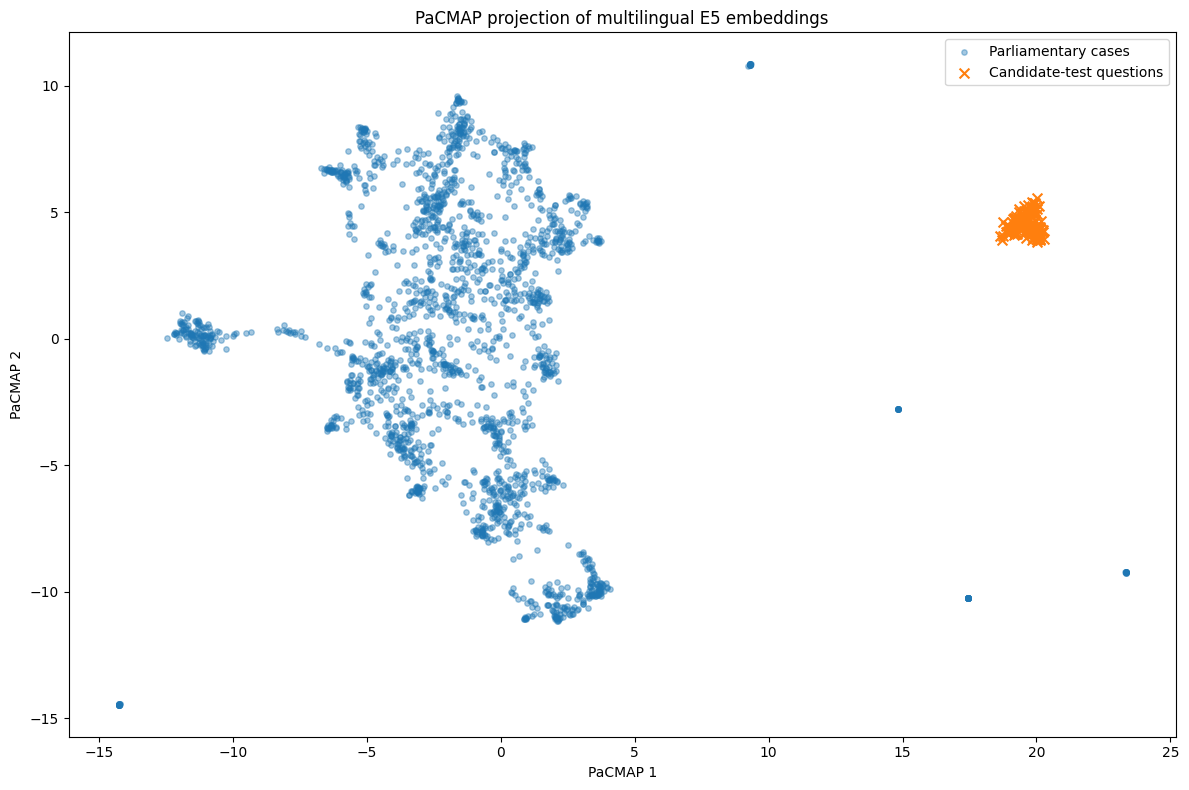

In [34]:
cases = df_pacmap[
    df_pacmap["type"] == "parliamentary_case"
]

questions = df_pacmap[
    df_pacmap["type"] == "candidate_question"
]

plt.figure(figsize=(12, 8))

plt.scatter(
    cases["pacmap_x"],
    cases["pacmap_y"],
    alpha=0.4,
    s=15,
    label="Parliamentary cases",
)

plt.scatter(
    questions["pacmap_x"],
    questions["pacmap_y"],
    s=50,
    marker="x",
    label="Candidate-test questions",
)

plt.xlabel("PaCMAP 1")
plt.ylabel("PaCMAP 2")
plt.title(
    "PaCMAP projection of multilingual E5 embeddings"
)

plt.legend()
plt.tight_layout()
plt.show()

The PaCMAP projection shows a strong separation between query embeddings representing candidate-test questions and document embeddings representing parliamentary cases. Within the parliamentary-case embeddings, several local structures and smaller clusters are also visible.

The internal structure among parliamentary cases—is much more interesting.

## Control plot

PaCMAP where candidate questions and parliamentary cases are encoded in the same role

In [35]:
question_embeddings_same = model.encode_document(
    question_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

case_embeddings_same = model.encode_document(
    case_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches: 100%|██████████| 67/67 [00:28<00:00,  2.37it/s]


In [36]:
embeddings_same = np.vstack([
    case_embeddings_same,
    question_embeddings_same,
])

print(embeddings_same.shape)

(2264, 768)


In [37]:
reducer_same = pacmap.PaCMAP(
    n_components=2,
    random_state=42,
)

embedding_2d_same = reducer_same.fit_transform(
    embeddings_same
)

In [38]:
df_pacmap["pacmap_same_x"] = embedding_2d_same[:, 0]
df_pacmap["pacmap_same_y"] = embedding_2d_same[:, 1]

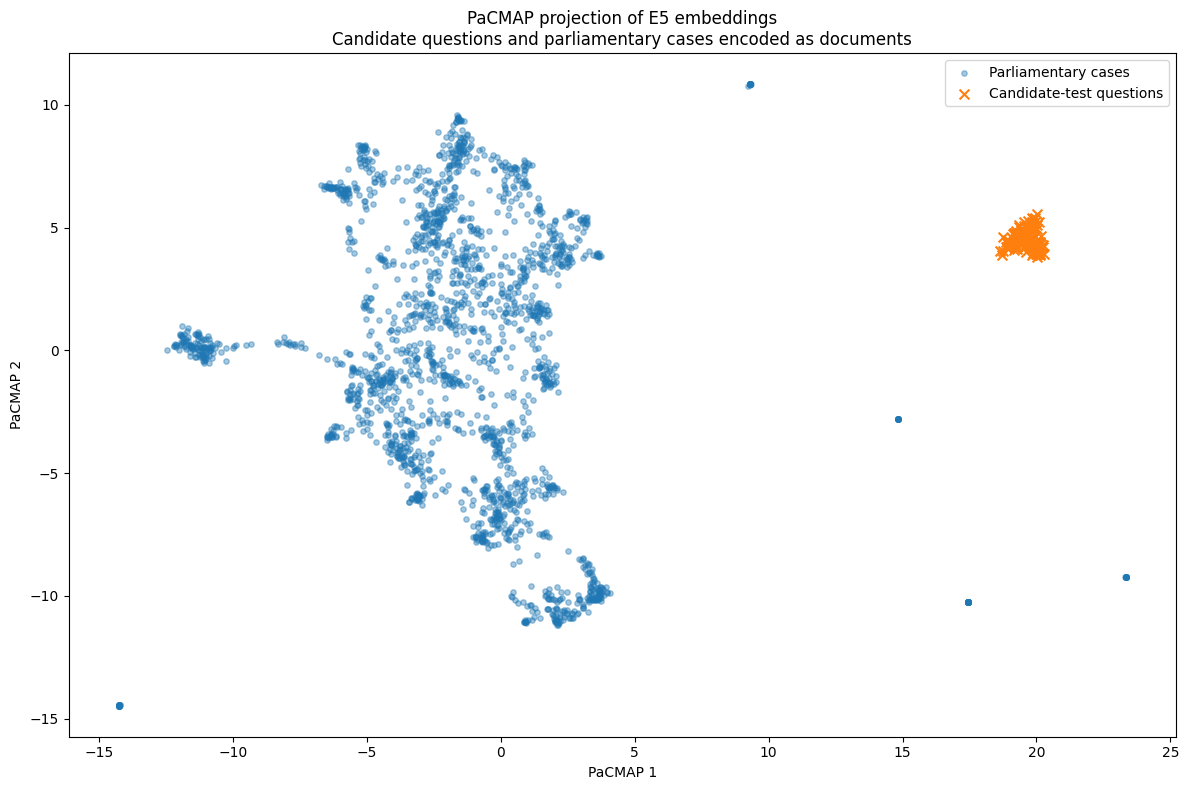

In [39]:
cases = df_pacmap[
    df_pacmap["type"] == "parliamentary_case"
]

questions = df_pacmap[
    df_pacmap["type"] == "candidate_question"
]

plt.figure(figsize=(12, 8))

plt.scatter(
    cases["pacmap_same_x"],
    cases["pacmap_same_y"],
    alpha=0.4,
    s=15,
    label="Parliamentary cases",
)

plt.scatter(
    questions["pacmap_same_x"],
    questions["pacmap_same_y"],
    s=50,
    marker="x",
    label="Candidate-test questions",
)

plt.xlabel("PaCMAP 1")
plt.ylabel("PaCMAP 2")
plt.title(
    "PaCMAP projection of E5 embeddings\n"
    "Candidate questions and parliamentary cases encoded as documents"
)

plt.legend()
plt.tight_layout()
plt.show()

# Pick one candidate-test question and highlight its top-10 E5 matches among all parliamentary cases

In [40]:
# Original asymmetric E5 embeddings and the original PaCMAP coordinates

pd.set_option("display.max_colwidth", None)

df_questions[
    ["Question", "election"]
].reset_index()

,index,Question,election
0,0,Den danske krone skal erstattes med euroen,FV11
1,1,EU skal fortsætte forhandlingerne med Tyrkiet med henblik på at opnå fuldt tyrkisk medlemskab af Unionen,FV11
2,2,Kirke og stat skal adskilles,FV11
3,3,Christiansborg favoriserer hovedstadsområdet på bekostning af resten af landet,FV11
4,4,"Folketinget skal fastsætte kvoter, så der altid er mindst 40 procent kvinder i bestyrelser for børsnoterede virksomheder",FV11
...,...,...,...
131,131,Flere uddannelser skal rykkes ud på Sjælland,FV22
132,132,Kattegatforbindelsen er en god idé,FV22
133,133,Lynetteholm-projektet skal droppes,FV22
134,134,Prisen for at køre over Storebæltsbroen skal sænkes,FV22


In [41]:
question_idx = 73

selected_question = df_questions.iloc[question_idx]["Question"]

print(selected_question)

Integrationsydelsen skal hæves


In [42]:
query_embedding = question_embeddings[question_idx]

similarities = query_embedding @ case_embeddings.T

In [43]:
top_k = 10

top_indices = np.argsort(similarities)[::-1][:top_k]

top_matches = df_cases_pacmap.iloc[top_indices].copy()

top_matches["similarity"] = similarities[top_indices]
top_matches["rank"] = range(1, top_k + 1)

In [44]:
top_matches[
    [
        "rank",
        "similarity",
        "sag_nummer",
        "sag_titel",
    ]
]

,rank,similarity,sag_nummer,sag_titel
1326,1,0.858032,L 202,Forslag til lov om ændring af lov om integrationsgrunduddannelse (igu). (Udvidelse af målgruppen m.v. for integrationsgrunduddannelsen).
665,2,0.857831,L 120,"Forslag til lov om ændring af lov om aktiv socialpolitik, integrationsloven, lov om en aktiv beskæftigelsesindsats og ligningsloven. (Nedsættelse af integrationsydelse og omlægning af dansktillæg)."
1756,3,0.854642,L 82,Forslag til lov om ændring af lov om integrationsgrunduddannelse (igu) og lov om Arbejdsgivernes Uddannelsesbidrag. (Videreførelse og udvidelse af igu-ordningen og videreførelse af egu-fgu-bonusordningen).
1109,4,0.852472,L 165 A,Forslag til lov om ændring af aktiesparekontoloven. (Forhøjelse af loftet for indskud på aktiesparekontoen).
978,5,0.851831,L 19,"Forslag til lov om ændring af lov om social pension, lov om højeste, mellemste, forhøjet almindelig og almindelig førtidspension m.v. og lov om en skattefri seniorpræmie. (Forhøjelse af fradragsbeløb for folkepension og førtidspension og forøgelse af skattefri seniorpræmie)."
240,6,0.851046,L 111,"Forslag til lov om ændring af lov om aktiv socialpolitik, integrationsloven og forskellige andre love. (Udvidelse af personkredsen for modtagelse af integrationsydelse m.v.)."
765,7,0.850252,L 231,"Forslag til lov om ændring af udlændingeloven. (Reform af reglerne om ægtefællesammenføring med nyt integrationskrav i stedet for tilknytningskravet, skærpet boligkrav m.v.)."
143,8,0.849641,L 2,"Forslag til lov om ændring af lov om aktiv socialpolitik, lov om en aktiv beskæftigelsesindsats, integrationsloven og forskellige andre love. (Indførelse af en integrationsydelse, ændring af reglerne om ret til uddannelses- og kontanthjælp m.v.)."
506,9,0.849191,L 161,Forslag til lov om ændring af udlændingeloven. (Forhøjelse af mindstebeløbet i beløbsordningen).
1827,10,0.848253,L 157,"Forslag til lov om ændring af udlændingeloven, lov om danskuddannelse til voksne udlændinge m.fl. og integrationsloven og forskellige andre love. (Ny opholdsordning for medfølgende familie til hjemvendende udlandsdanskere med visse beskæftigelsesmæssige kvalifikationer, justering af sprogkravet og halvering af den økonomiske sikkerhedsstillelse i ægtefællesammenføringssager, etablering af en lukket opgavebank for danskprøver m.v.)."


In [45]:
question_pacmap_idx = len(df_cases_pacmap) + question_idx

selected_question_point = df_pacmap.iloc[
    question_pacmap_idx
]

In [46]:
selected_question_point[
    ["text", "pacmap_x", "pacmap_y"]
]

text        Integrationsydelsen skal hæves
pacmap_x                         19.990143
pacmap_y                          4.341196
Name: 2201, dtype: object

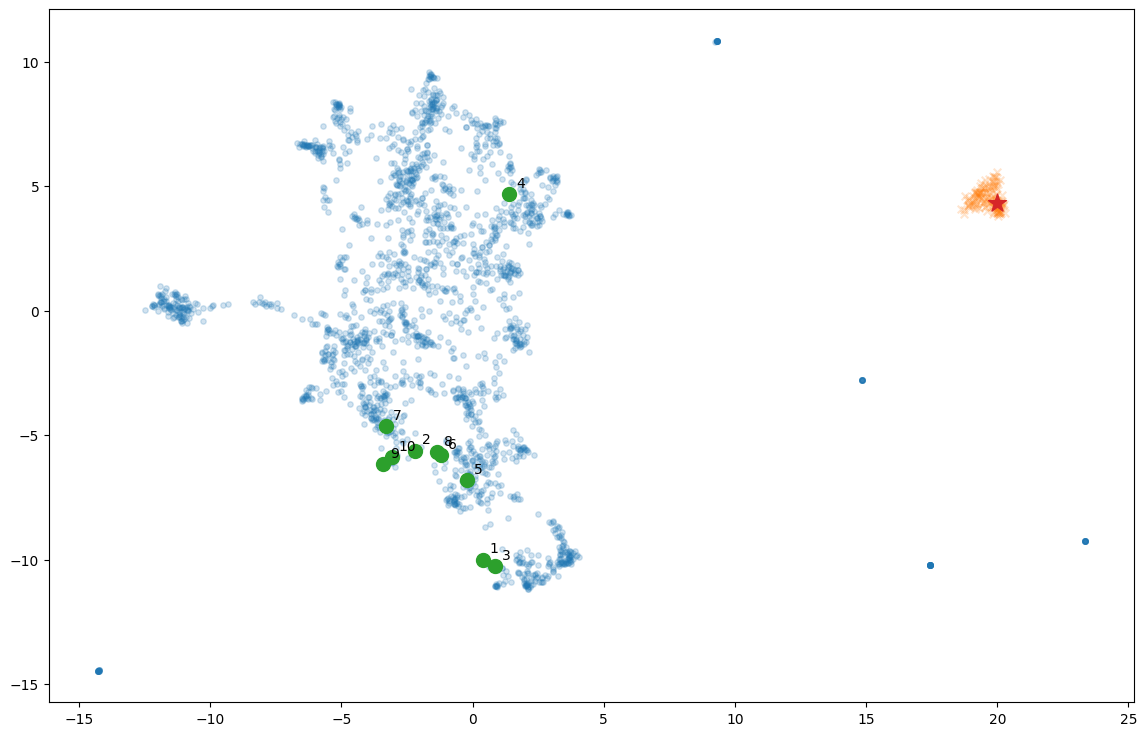

In [51]:
plt.figure(figsize=(14, 9))

# All parliamentary cases
plt.scatter(
    cases["pacmap_x"],
    cases["pacmap_y"],
    alpha=0.2,
    s=15,
    label="All parliamentary cases",
)

# All candidate questions
plt.scatter(
    questions["pacmap_x"],
    questions["pacmap_y"],
    alpha=0.2,
    s=30,
    marker="x",
    label="All candidate-test questions",
)

# Top-10 parliamentary matches
plt.scatter(
    df_pacmap.iloc[top_indices]["pacmap_x"],
    df_pacmap.iloc[top_indices]["pacmap_y"],
    s=100,
    marker="o",
    label="Top 10 E5 matches",
)

for rank, case_idx in enumerate(top_indices, start=1):

    point = df_pacmap.iloc[case_idx]

    plt.annotate(
        str(rank),
        (
            point["pacmap_x"],
            point["pacmap_y"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
    )

    

# Selected candidate question
plt.scatter(
    selected_question_point["pacmap_x"],
    selected_question_point["pacmap_y"],
    s=180,
    marker="*",
    label="Selected candidate question",
)

In [52]:
top_matches[
    [
        "rank",
        "similarity",
        "sag_nummer",
        "sag_titel",
        "sag_resume",
    ]
]

,rank,similarity,sag_nummer,sag_titel,sag_resume
1326,1,0.858032,L 202,Forslag til lov om ændring af lov om integrationsgrunduddannelse (igu). (Udvidelse af målgruppen m.v. for integrationsgrunduddannelsen).,"Det foreslås med lovforslaget, at opholdsbetingelsen for integrationsuddannelsesforløb udvides med 5 år, således at flygtninge og familiesammenførte til flygtninge, som har været i Danmark i 0-10 år, fremover får mulighed for at tage et integrationsgrunduddannelsesforløb. Derudover foreslås det, at omfanget af uddannelse i form af amu og sprogkurser udvides med 3 uger, hvorved der samlet set vil være 23 ugers uddannelse i et samlet integrationsgrundsuddannelsesforløb. \n\nLovforslaget udmønter dele af trepartsaftalen af 21. december 2020 mellem regeringen (Socialdemokratiet) og arbejdsmarkedets parter om at udvide og forbedre integrationsuddannelsesforløb.\n\nDet foreslås, at loven træder i kraft den 1. maj 2021, og at de foreslåede regler alene gælder for integrationsgrunduddannelsesforløb, der påbegyndes den 1. maj 2021 eller senere.\n"
665,2,0.857831,L 120,"Forslag til lov om ændring af lov om aktiv socialpolitik, integrationsloven, lov om en aktiv beskæftigelsesindsats og ligningsloven. (Nedsættelse af integrationsydelse og omlægning af dansktillæg).","Med lovforslaget nedsættes integrationsydelsen med 3 pct. for at skabe incitament til at tage et arbejde. Samtidig omlægges dansktillægget til en tidsbegrænset danskbonus bestående af seks rater af 1.500 kr. pr. måned. Derudover indføres en danskbonus på 6.000 kr. til personer på integrationsprogrammet, der ikke er omfattet af integrationsydelse."
1756,3,0.854642,L 82,Forslag til lov om ændring af lov om integrationsgrunduddannelse (igu) og lov om Arbejdsgivernes Uddannelsesbidrag. (Videreførelse og udvidelse af igu-ordningen og videreførelse af egu-fgu-bonusordningen).,"Formålet med forslaget er at videreføre og udvide integrationsgrunduddannelsesordningen (igu). Forslaget indebærer, at igu-ordningen og egu-bonussen videreføres i 4 år frem til den 31. december 2027. Forslaget bygger på en aftale mellem regeringen (Socialdemokratiet, Venstre og Moderaterne) og arbejdsmarkedets parter på baggrund af en anbefaling fra Reformkommissionen. \n\nDerudover indebærer forslaget, at persongruppen, som har adgang til ordningen, udvides til at omfatte alle former for familiesammenførte i alderen 18-40 år, som har været i Danmark i op til 20 år. I forlængelse heraf indføres der et årligt loft over antallet af nye igu-forløb på 1.500, hvor der efter behov og nærmere drøftelse i aftalekredsen kan indføres et midlertidigt stop, når der i det enkelte år er påbegyndt 1.200 igu-forløb. Forslaget vil endvidere give udlændinge- og integrationsministeren mulighed for at fastsætte nærmere regler for udstedelse af beviser til fuldførte og delvis gennemførte igu-forløb. \n\nForslaget indebærer også, at egu-fgu-bonusordningen forlænges med 4 år. \n\nDet foreslås, at loven træder i kraft den 1. januar 2024.\n"
1109,4,0.852472,L 165 A,Forslag til lov om ændring af aktiesparekontoloven. (Forhøjelse af loftet for indskud på aktiesparekontoen).,Det foreslås med lovforslaget at forhøje loftet for indskud på aktiesparekontoen fra 50.000 kr. i 2019 til 100.000 kr. i 2020.
978,5,0.851831,L 19,"Forslag til lov om ændring af lov om social pension, lov om højeste, mellemste, forhøjet almindelig og almindelig førtidspension m.v. og lov om en skattefri seniorpræmie. (Forhøjelse af fradragsbeløb for folkepension og førtidspension og forøgelse af skattefri seniorpræmie).","Lovforslaget udmønter dele af ”Aftale om ret til seniorpension for nedslidte”, og det foreslås\n\n- at bundfradraget for folkepensionisters indtægt ved personligt arbejde forhøjes fra 100.008 kr. til 122.004 kr. om året\n\n- at aftrapningen lempes for folkepensionister og førtidspensionister på gammel ordning (med tilkendelse før 2003), der er gift eller samlevende med en ikke-pensionist, fra 50 procent af indtægten op til 307.700 kr. til 54 